# Setup

In [38]:
import os
from collections.abc import Iterable
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import rdkit
import seaborn as sns
from rdkit import Chem, DataStructs
from rdkit.Chem import Descriptors, Lipinski, rdFingerprintGenerator

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().parent.resolve()
DATA_DIR = Path(os.environ.get("DATA_DIR"))

tox21_df = pd.read_csv(DATA_DIR / "tox21.csv")
print(tox21_df.shape)

(7831, 14)


## Common functions

In [ ]:
def print_descriptors(mol: rdkit.Chem.rdchem.Mol):
    mol_weight = Descriptors.MolWt(mol)
    log_p = Descriptors.MolLogP(mol)
    tpsa = Descriptors.TPSA(mol)
    molar_refractivity = Descriptors.MolMR(mol)
    rot_bonds = Lipinski.NumRotatableBonds(mol)
    h_donors = Lipinski.NumHDonors(mol)
    h_acceptors = Lipinski.NumHAcceptors(mol)
    fsp3 = Lipinski.FractionCSP3(mol)
    aromatic_rings = Lipinski.NumAromaticRings(mol)
    heavy_atoms = Lipinski.HeavyAtomCount(mol)

    display(
        pd.DataFrame(
            {
                "Molecular Weight": f"{mol_weight:.2f} g/mol",
                "Calculated LogP (Wildman)": f"{log_p:.2f}",
                "Rotatable Bonds": rot_bonds,
                "H-Bond Donors": h_donors,
                "H-Bond Acceptors": h_acceptors,
                "TPSA": f"{tpsa:.2f} Å²",
                "Fraction CSP3 (Fsp3)": f"{fsp3:.2f}",
                "Molar Refractivity": f"{molar_refractivity:.2f}",
                "Aromatic Rings": aromatic_rings,
                "Heavy Atom Count": heavy_atoms,
            },
            index=[0],
        )
    )


def visualize_graph(graph: nx.Graph):
    labels = nx.get_node_attributes(graph, "element")

    # Render the layout
    pos = nx.spring_layout(graph, seed=42)
    nx.draw(
        graph,
        pos,
        labels=labels,
        with_labels=True,
        node_color="lightblue",
        font_weight="bold",
        node_size=500,
    )
    plt.show()


def make_adjacency_matrix(graph: nx.Graph):
    binary_matrix = nx.adjacency_matrix(graph)
    print("Binary Adjacency Matrix:")
    print(binary_matrix.toarray())

    weighted_matrix = nx.adjacency_matrix(graph, weight="bond_type")
    print("\nBond-Weighted Adjacency Matrix:")
    print(weighted_matrix.toarray())

    df_adj = nx.to_pandas_adjacency(graph, weight="bond_type")
    print("\nPandas DataFrame Adjacency Matrix View:")
    # display(df_adj.iloc[:5, :5])
    display(df_adj)
    return binary_matrix, weighted_matrix, df_adj


def make_graph(mol: rdkit.Chem.rdchem.Mol):
    graph = nx.Graph()

    # Add nodes (atoms) with features
    for atom in mol.GetAtoms():
        graph.add_node(
            atom.GetIdx(),
            atomic_num=atom.GetAtomicNum(),
            element=atom.GetSymbol(),
            formal_charge=atom.GetFormalCharge(),
        )

    # Add edges (bonds) with features
    for bond in mol.GetBonds():
        graph.add_edge(
            bond.GetBeginAtomIdx(),
            bond.GetEndAtomIdx(),
            bond_type=bond.GetBondTypeAsDouble(),  # 1.0 for single, 2.0 for double, 1.5 for aromatic
        )

    print(f"Total Atoms (Nodes): {graph.number_of_nodes()}")
    print(f"Total Bonds (Edges): {graph.number_of_edges()}")

    return graph


def calculate_laplacian(adjacency_matrix: Iterable):
    degree = np.diag(adjacency_matrix.sum(axis=1))
    laplacian = degree - adjacency_matrix
    eigenvalues = np.linalg.eigvalsh(laplacian)

    # display(pd.DataFrame(adjacency_matrix, index=atom_labels, columns=atom_labels))
    print("Degree sequence:", np.diag(degree))
    print("Laplacian eigenvalues:", np.round(eigenvalues, 4))
    return laplacian


def show_graph_node_degree(graph: nx.Graph, adjacency_matrix):
    degrees = adjacency_matrix.sum(axis=1)
    labels = nx.get_node_attributes(graph, "element").values()
    degree_df = pd.DataFrame({"atom": labels, "degree": degrees})
    print("Node Degree:")
    display(degree_df)

    plt.figure(figsize=(6, 4))
    sns.barplot(data=degree_df, x="atom", y="degree")
    plt.title("Node Degree in a Molecular Graph")
    plt.show()


def show_laplacian(graph: nx.Graph, laplacian: Iterable):
    atom_labels = nx.get_node_attributes(graph, "element").values()

    plt.figure(figsize=(6, 4))
    sns.heatmap(
        laplacian,
        annot=True,
        cmap="crest",
        xticklabels=atom_labels,
        yticklabels=atom_labels,
    )
    plt.title("Graph Laplacian")
    plt.show()

# Bipartite Graphs for Molecule-Assay Data

The molecules connect to assays when a label is active. This creates a bipartite graph with molecule nodes on one side and assay nodes on the other.

- one partition is molecules
- the other partition is assays
- an edge indicates activity or measured participation

This is especially useful for Tox21, SIDER, MUV, and ToxCast.

,assay,active_edges_in_sample
0,SR-ARE,942.0
1,SR-MMP,918.0
2,NR-ER,793.0
3,NR-AhR,768.0
4,SR-p53,423.0
5,SR-HSE,372.0
6,NR-ER-LBD,350.0
7,NR-AR,309.0
8,NR-Aromatase,300.0
9,SR-ATAD5,264.0


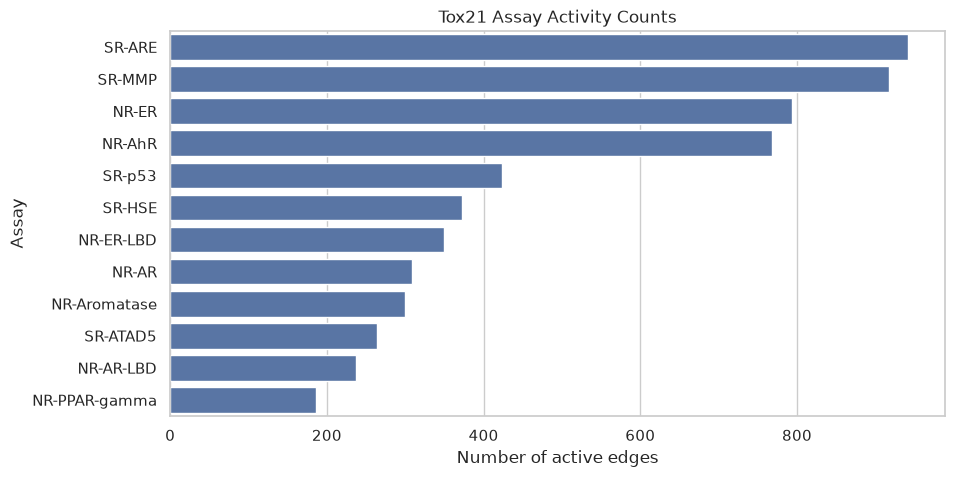

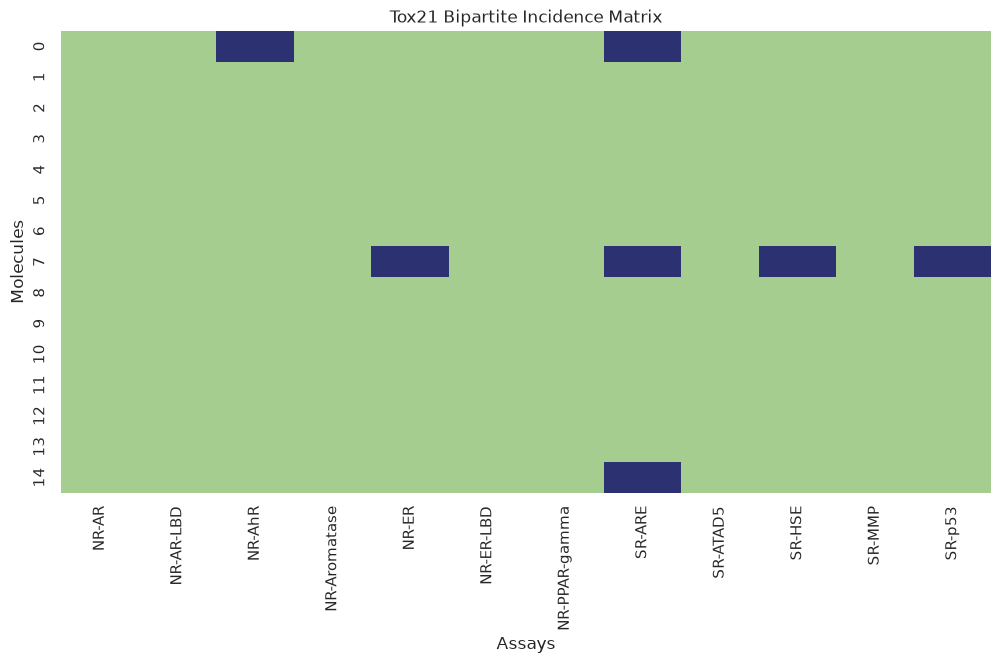

In [53]:
def show_bipartite_graph(activity_counts: pd.DataFrame):
    df = activity_counts.sum().sort_values(ascending=False)
    activity_df = df.reset_index()
    activity_df.columns = ["assay", "active_edges_in_sample"]
    display(activity_df.head(12))

    plt.figure(figsize=(10, 5))
    sns.barplot(data=activity_df.head(12), x="active_edges_in_sample", y="assay")
    plt.title("Tox21 Assay Activity Counts")
    plt.xlabel("Number of active edges")
    plt.ylabel("Assay")
    plt.show()


def show_bipartite_incidence_matrix(activity_counts: pd.DataFrame):
    plt.figure(figsize=(12, 6))
    sns.heatmap(activity_counts.iloc[:15, :12], cmap="crest", cbar=False)
    plt.title("Tox21 Bipartite Incidence Matrix")
    plt.xlabel("Assays")
    plt.ylabel("Molecules")
    plt.show()


assay_cols = [col for col in tox21_df.columns if col not in {"mol_id", "smiles"}]
activity_counts = tox21_df[assay_cols].fillna(0)
show_bipartite_graph(activity_counts)
show_bipartite_incidence_matrix(activity_counts)

# Ethoxzolamide

'CCOc1ccc2nc(S(N)(=O)=O)sc2c1'

,Molecular Weight,Calculated LogP (Wildman),Rotatable Bonds,H-Bond Donors,H-Bond Acceptors,TPSA,Fraction CSP3 (Fsp3),Molar Refractivity,Aromatic Rings,Heavy Atom Count
0,258.32 g/mol,1.34,3,1,5,82.28 Å²,0.22,62.16,2,16


Total Atoms (Nodes): 16
Total Bonds (Edges): 17


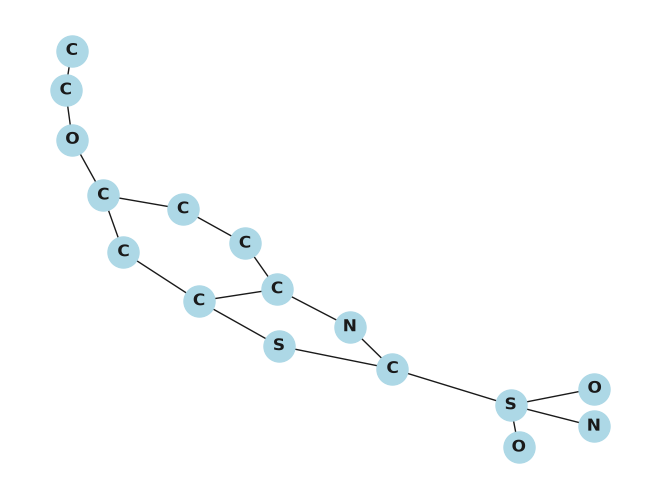

{69: ((2, 2),),
 80: ((1, 0),),
 159: ((8, 2),),
 162: ((13, 1),),
 237: ((1, 2),),
 294: ((0, 1),),
 322: ((3, 1),),
 350: ((9, 0),),
 371: ((9, 2),),
 378: ((7, 0),),
 485: ((8, 1),),
 493: ((15, 2),),
 557: ((6, 2),),
 650: ((11, 0), (12, 0)),
 675: ((13, 0),),
 695: ((2, 0),),
 705: ((7, 2),),
 718: ((4, 2),),
 833: ((9, 1),),
 875: ((15, 1),),
 885: ((14, 1),),
 961: ((5, 2),),
 1057: ((0, 0),),
 1080: ((13, 2),),
 1097: ((6, 1),),
 1171: ((10, 0),),
 1238: ((1, 1),),
 1380: ((3, 0), (6, 0), (8, 0), (14, 0)),
 1452: ((2, 1),),
 1476: ((11, 1), (12, 1)),
 1501: ((3, 2),),
 1607: ((10, 1),),
 1669: ((14, 2),),
 1750: ((4, 1), (5, 1)),
 1855: ((7, 1),),
 1873: ((4, 0), (5, 0), (15, 0))}

'CCN1C(=O)NC(c2ccccc2)C1=O'

,Molecular Weight,Calculated LogP (Wildman),Rotatable Bonds,H-Bond Donors,H-Bond Acceptors,TPSA,Fraction CSP3 (Fsp3),Molar Refractivity,Aromatic Rings,Heavy Atom Count
0,204.23 g/mol,1.30,2,1,2,49.41 Å²,0.27,55.10,1,15


Total Atoms (Nodes): 15
Total Bonds (Edges): 16


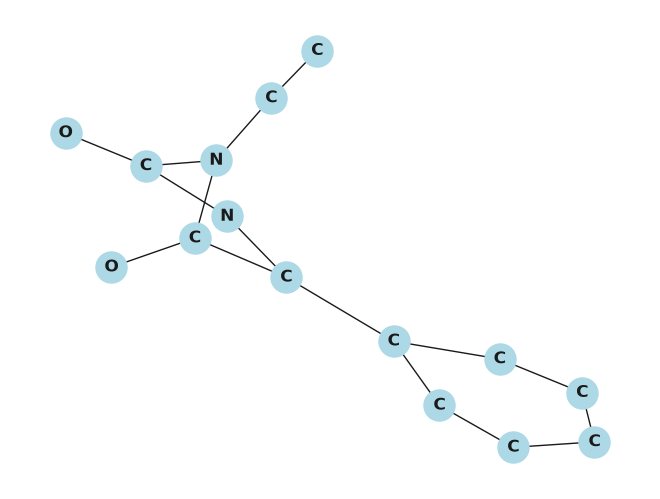

Binary Adjacency Matrix:
[[0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 1 0 0 0 0 0 0 0 0 0 1 0]
 [0 0 1 0 1 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 1 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 1 0 1 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 1 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 1 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 1 0 0 0]
 [0 0 1 0 0 0 1 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]]

Bond-Weighted Adjacency Matrix:
[[0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. ]
 [1.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. ]
 [0.  1.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1.  0. ]
 [0.  0.  1.  0.  2.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0. ]
 [0.  0.  0.  2.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. ]
 [0.  0.  0.  1.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0. ]
 [0.  0.  0.  0.  0.  1.  0.  1.  0.  0.  0.  0.  0.  1.  0. ]
 [0. 

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,1.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.5,0.0,0.0,0.0,1.5,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.5,0.0,1.5,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.5,0.0,1.5,0.0,0.0,0.0,0.0


Laplacian from binary adj matrix:
Degree sequence: [1 2 3 3 1 2 3 3 2 2 2 2 2 3 1]
Laplacian eigenvalues: [0.     0.1198 0.3765 0.5268 1.     1.     1.3875 1.8248 2.5152 3.
 3.     3.3974 4.073  4.7509 5.0282]


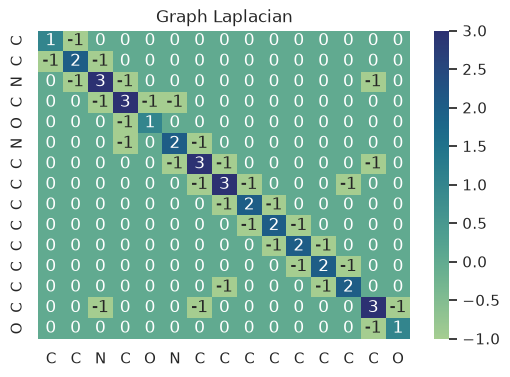

Laplacian from weighted adj matrix:
Degree sequence: [1. 2. 3. 4. 2. 2. 3. 4. 3. 3. 3. 3. 3. 4. 2.]
Laplacian eigenvalues: [-0.      0.1301  0.3972  0.6553  1.3472  1.5     1.867   2.      3.2809
  3.4536  4.5     4.9211  5.5974  5.9592  6.3908]


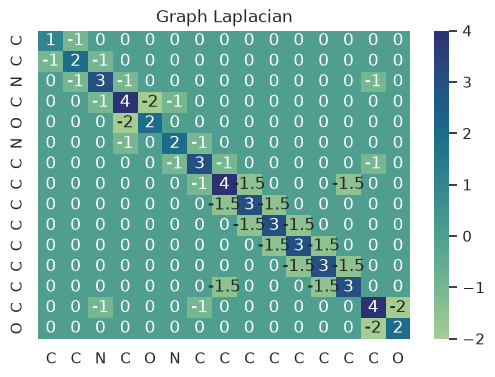

Node Degree:


,atom,degree
0,C,1
1,C,2
2,N,3
3,C,3
4,O,1
5,N,2
6,C,3
7,C,3
8,C,2
9,C,2


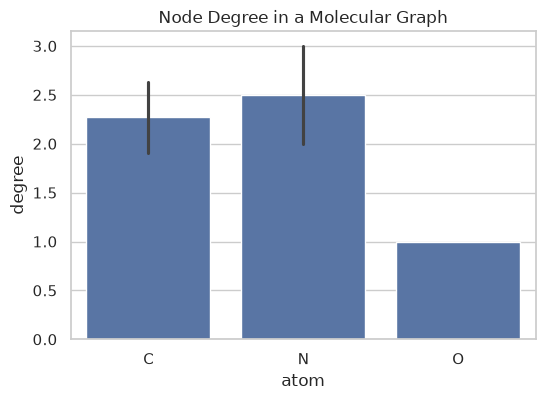

Ethoxzolamide Active Bits: 36
Acetazolamide Active Bits: 28
Tanimoto Similarity Index: 0.1228


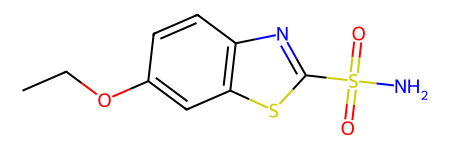

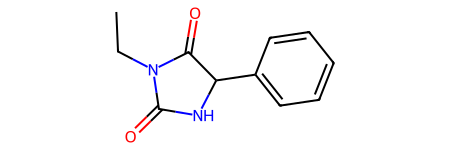

In [46]:
def process_ethoxzolamide():
    ethoxzolamide_smiles = tox21_df.loc[tox21_df["mol_id"] == "TOX3021"]["smiles"]
    display(ethoxzolamide_smiles.iloc[0])

    ethoxzolamide_mol = Chem.MolFromSmiles(ethoxzolamide_smiles.iloc[0])
    print_descriptors(ethoxzolamide_mol)
    visualize_graph(make_graph(ethoxzolamide_mol))

    # Generate Morgan Fingerprints (ECFP4 equivalent)
    # Radius=2 corresponds to a maximum diameter of 4 bonds (ECFP4)
    # fpSize=2048 is the standard bit-vector length to minimize bit collisions
    generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

    ao = rdFingerprintGenerator.AdditionalOutput()
    ao.AllocateBitInfoMap()

    # Generate Binary Bit Vector
    ethoxzolamide_fp = generator.GetFingerprint(ethoxzolamide_mol, additionalOutput=ao)
    display(ao.GetBitInfoMap())

    smiles = tox21_df.loc[tox21_df["mol_id"] != "TOX3021"]["smiles"]
    display(smiles.iloc[0])
    mol = Chem.MolFromSmiles(smiles.iloc[0])
    print_descriptors(mol)
    graph = make_graph(mol)
    visualize_graph(graph)
    binary_matrix, weighted_matrix, _ = make_adjacency_matrix(graph)
    print("Laplacian from binary adj matrix:")
    show_laplacian(graph, calculate_laplacian(binary_matrix))
    print("Laplacian from weighted adj matrix:")
    show_laplacian(graph, calculate_laplacian(weighted_matrix))
    show_graph_node_degree(graph, binary_matrix)

    finger_print = generator.GetFingerprint(mol)

    # Calculate Tanimoto Similarity (ranges from 0.0 to 1.0)
    tanimoto_similarity = DataStructs.TanimotoSimilarity(ethoxzolamide_fp, finger_print)

    print(f"Ethoxzolamide Active Bits: {ethoxzolamide_fp.GetNumOnBits()}")
    print(f"Acetazolamide Active Bits: {finger_print.GetNumOnBits()}")
    print(f"Tanimoto Similarity Index: {tanimoto_similarity:.4f}")

    display(ethoxzolamide_mol)
    display(mol)


process_ethoxzolamide()